In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Loading Data Set
df=pd.read_csv("Heart-Disease-Dataset.csv")
print("Dataset load Successfully")

Dataset load Successfully


In [6]:
#Viewing Datset
print("First Five Rows")
display(df.head())

First Five Rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
print("Last Five Rows")
display(df.tail())

Last Five Rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [9]:
# Data Set Shape
print("Dataset Shape:", df.shape)
# Columns Names
print("CoLumns Names")
print(df.columns.tolist())

Dataset Shape: (1025, 14)
CoLumns Names
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [10]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [11]:
# data Type
print("Data Types")
print(df.dtypes)

Data Types
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [13]:

# Checking Missing Values
missing_values=df.isnull().sum()
print("Missing Values")
print(missing_values)

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [16]:
# missing Value Percentage
missing_percentage=(df.isnull().sum()/len(df))*100
print("Missing value Percentage")
print(missing_percentage)


Missing value Percentage
age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64


In [17]:
# No Missing Value Is  in my Heart Disease Dataset

In [21]:
#Duplicate Rows
print("Duplicate Rows :",df.duplicated().sum())
# removing DupkicateRows
df=df.drop_duplicates()
#Shape After Removing Duplicate
print("Shape After removing Duplicate:", df.shape)

Duplicate Rows : 0
Shape After removing Duplicate: (302, 14)


In [22]:
# Descriptive Statistics
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [25]:
# Target Distribution
print ("Target Distribution")
display(df["target"].value_counts())
# target Percentage
print("Target  Percentage")
display(df["target"].value_counts(normalize=True)*100)

Target Distribution


target
1    164
0    138
Name: count, dtype: int64

Target  Percentage


target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

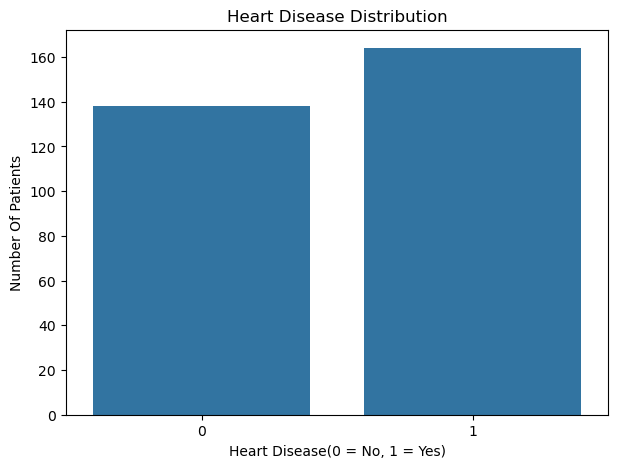

In [30]:
# Target Visualization Count Plot
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="target")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease(0 = No, 1 = Yes)")
plt.ylabel("Number Of Patients")
plt.show()

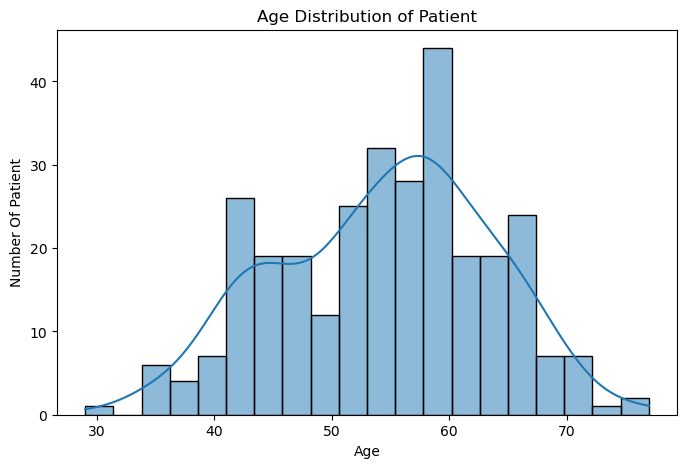

In [32]:
# Age Distribution Graph
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age",bins=20, kde=True)
plt.title("Age Distribution of Patient")
plt.xlabel("Age")
plt.ylabel("Number Of Patient")
plt.show()
           

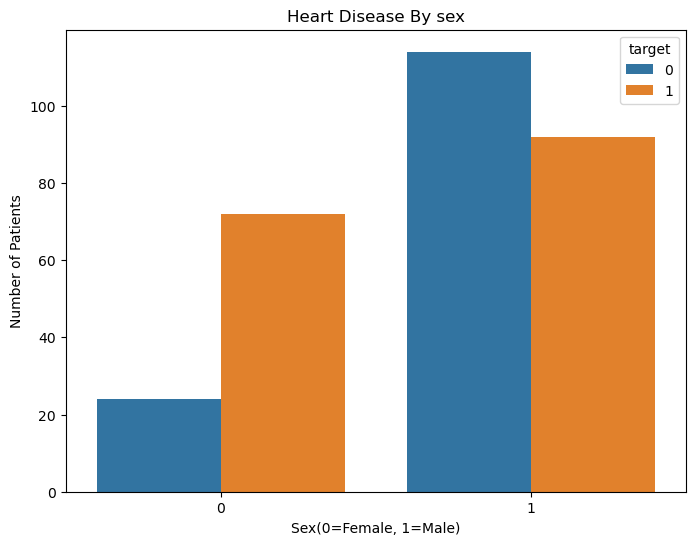

In [38]:
# Heart Disease By Sex
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="sex", hue="target")
plt.title("Heart Disease By sex")
plt.xlabel("Sex(0=Female, 1=Male)")
plt.ylabel("Number of Patients")
plt.show()

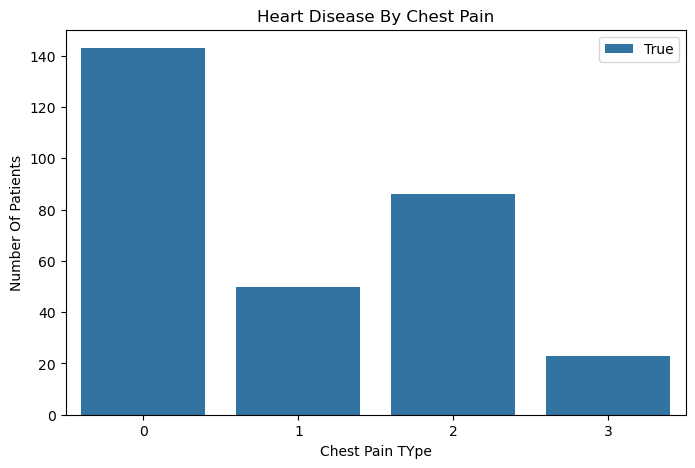

In [41]:
# Heart Disease By Chest Pain Type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="cp", hue=True)
plt.title("Heart Disease By Chest Pain")
plt.xlabel("Chest Pain TYpe")
plt.ylabel("Number Of Patients")
plt.show()

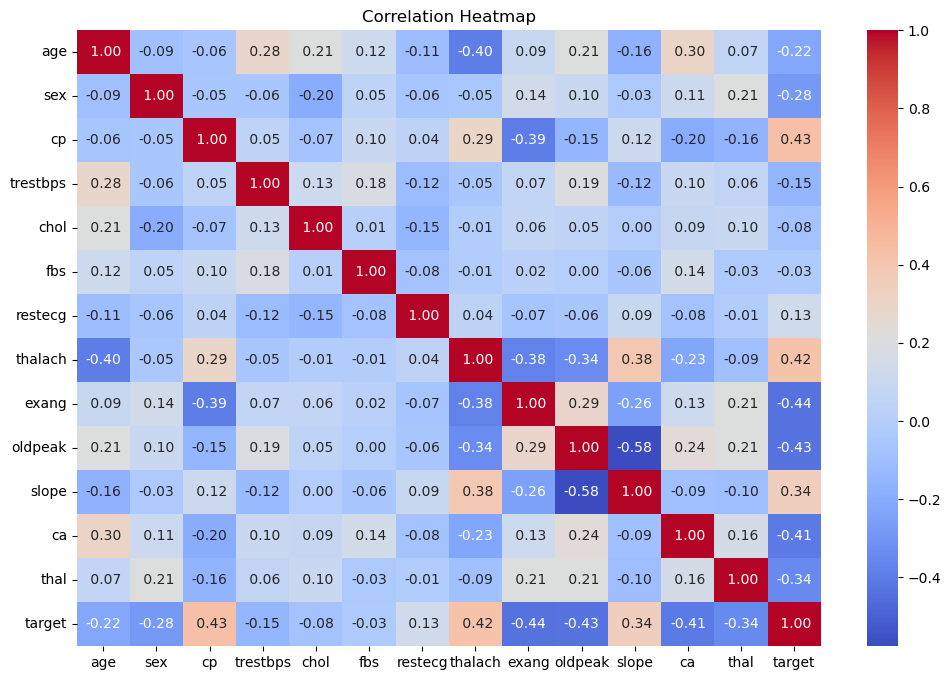

In [45]:
# Correlation Heat Map
plt.figure(figsize=(12,8))
correlation=df.corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=" .2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [48]:
# Seperating feature and Target
x=df.drop("target", axis=1)
y=df["target"]

print("Features:")
print(x.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target:
target


In [49]:
# Feature Selection
selected_features = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"
]

X = df[selected_features]
y = df["target"]

print("Selected Features:")
print(selected_features)


Selected Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [50]:
# Train Test Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (241, 13)
Testing data: (61, 13)


In [52]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [53]:
# Model 1 Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression completed.")

Logistic Regression completed.


In [54]:
# Model2 Decision Tree
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

tree_pred = decision_tree.predict(X_test)

print("Decision Tree completed.")

Decision Tree completed.


In [55]:
# Random Forest Model 3
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

forest_pred = random_forest.predict(X_test)

print("Random Forest completed.")

Random Forest completed.


In [56]:
# Model4 KNN KNeighbour Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN completed.")

KNN completed.


In [57]:
# Model Evaluation Statistics
models = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred,
    "KNN": knn_pred
}

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Decision Tree,0.770492,0.806452,0.757576,0.781250
2,Random Forest,0.754098,0.764706,0.787879,0.776119
3,KNN,0.786885,0.777778,0.848485,0.811594


In [59]:
# Showing Score as Percentage
results_percentage = results_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2)

display(results_percentage)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,80.33,80.00,84.85,82.35
1,Decision Tree,77.05,80.65,75.76,78.12
2,Random Forest,75.41,76.47,78.79,77.61
3,KNN,78.69,77.78,84.85,81.16


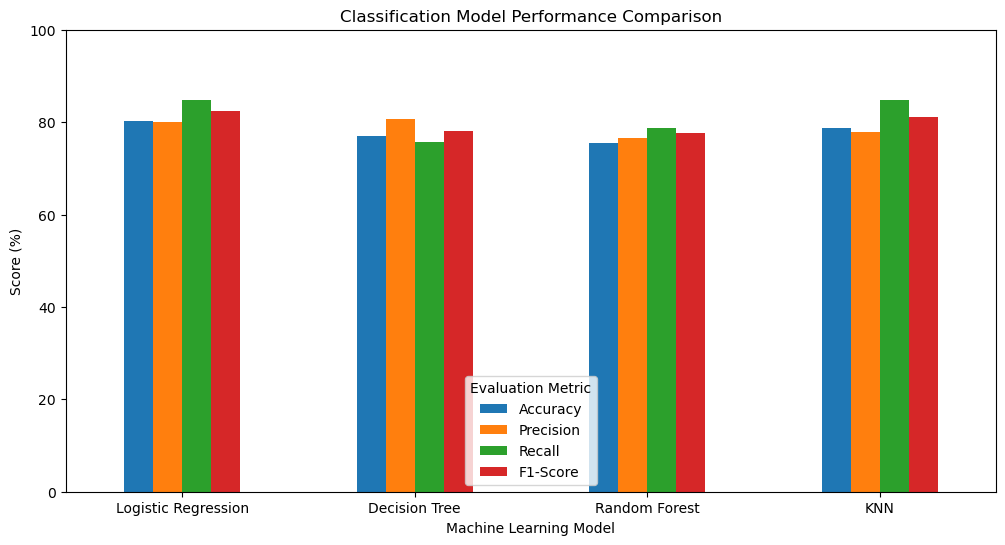

In [60]:
# Comparing Model BY BAR Graph
results_percentage.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)

plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")

plt.show()

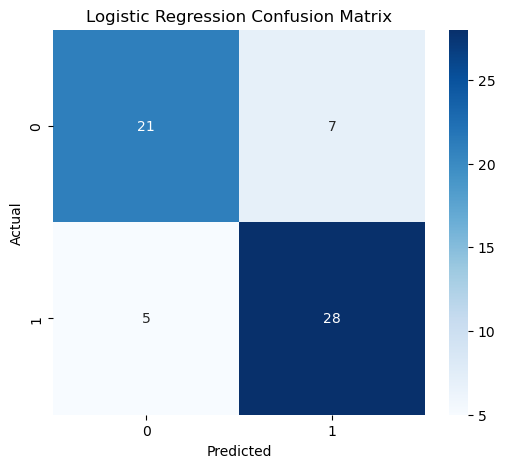

In [61]:
#Confusion Matrix Logistic Regression
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

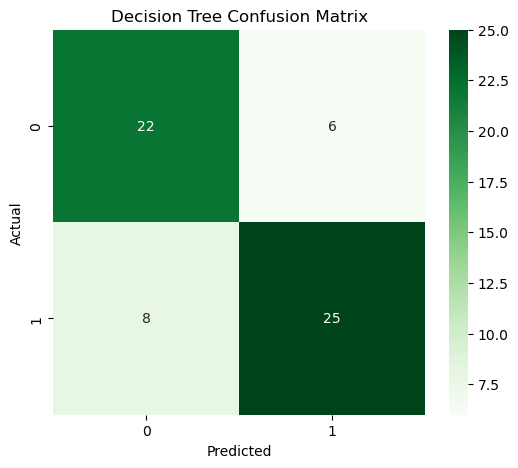

In [62]:
# Decision Tree By Heatmap
cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

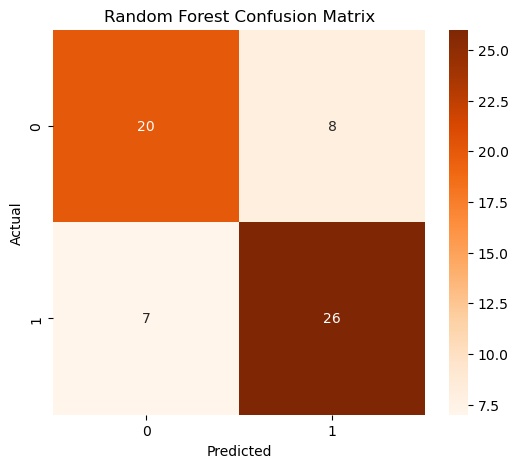

In [63]:
# Random Forest Confusion Matrix
cm = confusion_matrix(y_test, forest_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

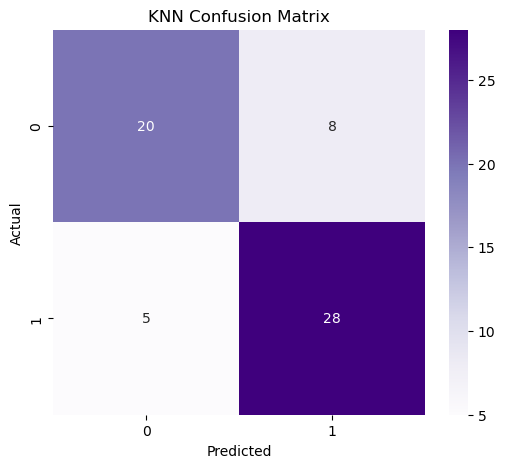

In [64]:
# KNN Confusion Matrix
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [65]:
# Classification Report
for model_name, predictions in models.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

Decision Tree
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        28
           1       0.81      0.76      0.78        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

Random Forest
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75   

In [67]:
# Random Forest Feature Importance
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
2,cp,0.173969
7,thalach,0.131634
11,ca,0.105700
9,oldpeak,0.096577
12,thal,0.090418
0,age,0.083049
8,exang,0.073679
3,trestbps,0.072088
4,chol,0.067384
1,sex,0.040229


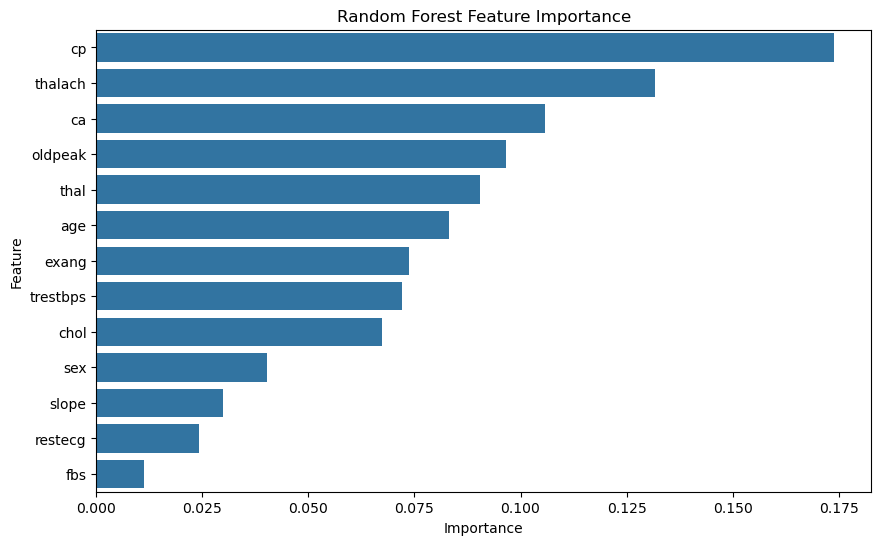

In [68]:
# Feature Importance Graph
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [69]:
# Prediction Model
new_patient = pd.DataFrame({
    "age": [55],
    "sex": [1],
    "cp": [0],
    "trestbps": [140],
    "chol": [250],
    "fbs": [0],
    "restecg": [1],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [1.0],
    "slope": [1],
    "ca": [0],
    "thal": [2]
})

new_patient_scaled = scaler.transform(new_patient)

prediction = logistic_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


In [70]:
# Best Model
best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("Best Model:")
print(best_model)


Best Model:
Model        Logistic Regression
Accuracy                0.803279
Precision                    0.8
Recall                  0.848485
F1-Score                0.823529
Name: 0, dtype: object


In [71]:
# Final Result
print("========== FINAL MODEL RESULTS ==========")

display(results_percentage)

print("\nBest Model Based on F1-Score:")
print(best_model["Model"])

print("\nBest F1-Score:")
print(best_model["F1-Score"], "%")

========== FINAL MODEL RESULTS ==========


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,80.33,80.00,84.85,82.35
1,Decision Tree,77.05,80.65,75.76,78.12
2,Random Forest,75.41,76.47,78.79,77.61
3,KNN,78.69,77.78,84.85,81.16



Best Model Based on F1-Score:
Logistic Regression

Best F1-Score:
0.8235294117647058 %


In [72]:
## Conclusion

#In this project, a Heart Disease Prediction classification system was developed using machine learning.

#The dataset was first inspected and preprocessed by checking data types, missing values, duplicate records, and descriptive statistics.

#Feature selection was performed using the available patient health-related variables, including age, sex, chest pain type, resting blood pressure, cholesterol, maximum heart rate, exercise-induced angina, and other clinical features.

#Four classification algorithms were trained and compared:

#1. Logistic Regression
#2. Decision Tree
#3. Random Forest
#4. K-Nearest Neighbors (KNN)

#The models were evaluated using Accuracy, Precision, Recall, and F1-Score.

#The model with the highest F1-Score was selected as the best-performing model. Feature importance from the Random Forest model was also analyzed to understand which variables contributed most to the prediction.

#Overall, this project demonstrates how machine learning can be applied to classify patients based on health-related features and support data-driven analysis.